In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Final_Sales_Pipeline.csv")

In [3]:
df.head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,won,2016-10-25,2017-03-02,517.0


In [4]:
df.columns = df.columns.str.strip().str.lower()

In [5]:
df.columns

Index(['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage',
       'engage_date', 'close_date', 'close_value'],
      dtype='object')

In [6]:
df['deal_stage'] = df['deal_stage'].str.strip().str.lower()


In [7]:
df['close_value'] = pd.to_numeric(df['close_value'],errors = 'coerce')
df['close_data'] = pd.to_datetime(df['close_date'])
df['engage_date'] = pd.to_datetime(df['engage_date'])

In [8]:
print(df.shape)

(8800, 9)


In [9]:
df.isnull().sum()

opportunity_id       0
sales_agent          0
product              0
account           1425
deal_stage           0
engage_date        500
close_date        2089
close_value          0
close_data        2089
dtype: int64

In [10]:
total_deals = df.shape[0]
total_revenue = df['close_value'].sum()
won_deals = df[df['deal_stage']=='won'].shape[0]

conversion_rate = won_deals/total_deals
avg_deal_value = df['close_value'].mean()



In [11]:
print("Total deals",total_deals)

Total deals 8800


In [12]:
print("Total Revenue",total_revenue)

Total Revenue 10005534.0


In [13]:
print("Won deals",won_deals)

Won deals 4238


In [14]:
print("Conversion Rates",conversion_rate)

Conversion Rates 0.48159090909090907


In [15]:
print("Average deal value:",avg_deal_value)

Average deal value: 1136.9925


In [16]:
stage_counts = df['deal_stage'].value_counts()
print(stage_counts)

deal_stage
won            4238
lost           2473
engaging       1589
prospecting     500
Name: count, dtype: int64


<Axes: xlabel='deal_stage'>

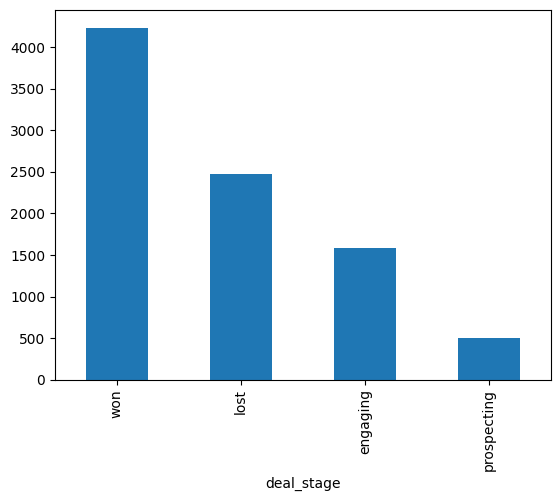

In [17]:
stage_counts.plot(kind='bar')

In [18]:
revenue_stage = df.groupby('deal_stage')['close_value'].sum()

In [32]:
print(revenue_stage)

deal_stage
engaging              0.0
lost                  0.0
prospecting           0.0
won            10005534.0
Name: close_value, dtype: float64


In [22]:
df['close_date'] = pd.to_datetime(df['close_date'], errors='coerce')

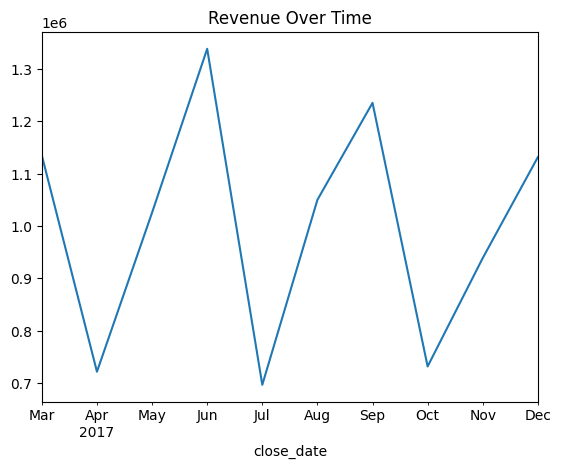

In [23]:
df.groupby(df['close_date'].dt.to_period('M'))['close_value'].sum().plot()
plt.title("Revenue Over Time")
plt.show()

In [24]:
stage_percent = df['deal_stage'].value_counts(normalize=True)*100

In [25]:
stage_percent

deal_stage
won            48.159091
lost           28.102273
engaging       18.056818
prospecting     5.681818
Name: proportion, dtype: float64

In [26]:
won = df[df['deal_stage'] == 'won']['close_value'].dropna()

In [27]:
lost = df[df['deal_stage']=='lost']['close_value'].dropna()

In [28]:
print("won count",len(won))

won count 4238


In [29]:
print("Lost count",len(lost))

Lost count 2473


In [30]:
#done